In [1]:
from wiki_dump_reader import Cleaner, iterate
from tqdm import tqdm
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from collections import Counter
import math
from tabulate import tabulate
import psutil
import os


In [2]:
languages = ["English","Bengali","Hindi"]
# languages = ["English","Hindi"]
lang = [l.lower() for l in languages]

dump_files = [f"/mnt/Velocity_Vault/Wiki_Dump/Dump/{l}_dump.xml" for l in lang]
raw_corpus_files = [f"/mnt/Velocity_Vault/Wiki_Dump/Corpus/{l}_corpus.txt" for l in lang]
corpus_files = [f"/mnt/Velocity_Vault/Wiki_Dump/Corpus/{l}_processed.txt" for l in lang]


In [3]:

def write_corpus(dump,corpus):
    cleaner = Cleaner()
    
    # First, count the total number of pages for the progress bar
    total_pages = sum(1 for _ in iterate(dump))
    # print(f" {total_pages} pages to process.")
    
    with open(corpus, 'w', encoding='utf-8') as output:
        
        with tqdm(iterate(dump), total=total_pages, unit="page") as pbar:
            for title, text in pbar:
                
                text = cleaner.clean_text(text)                
                cleaned_text, _ = cleaner.build_links(text)
                output.write(title + '\n' + cleaned_text + '\n') # type: ignore
                    
    print(f"Corpus saved to: {corpus}")

# for l,dump_file,raw_corpus_file in zip(languages,dump_files,raw_corpus_files):
#     print("Constructing Corpus for ",l)
#     write_corpus(dump_file,raw_corpus_file)


In [4]:

def clean_hindi_line(line):
    cleaned = re.sub(r'[^\u0900-\u097F ]', ' ', line)
    cleaned = re.sub(r'[\u0966-\u096F]', ' ', cleaned)
    cleaned = re.sub(r'[।॥]', ' ', cleaned)
    cleaned = re.sub(r' +', ' ', cleaned)
    cleaned = cleaned.strip()
    return cleaned

def clean_bengali_line(line):
    
    cleaned = re.sub(r'[^\u0980-\u09FF ]', ' ', line)
    cleaned = re.sub(r' +', ' ', cleaned)
    cleaned = cleaned.strip()
    
    return cleaned

def clean_english_line(line):
    
    line = line.lower()
    cleaned = re.sub(r'[^a-z ]', ' ', line)
    cleaned = re.sub(r' +', ' ', cleaned)
    cleaned = cleaned.strip()
    
    return cleaned

language_cleaner = {"Hindi":clean_hindi_line,
                    "Bengali":clean_bengali_line,
                    "English":clean_english_line}

In [5]:

def preprocess_corpus(clean_line,source_file, dest_file):
    
    total_lines=0
    
    with open(source_file, 'r', encoding='utf-8') as src:
        total_lines=0
        for _ in src:
            total_lines+=1
            
    # print(f"Found {total_lines} lines to process.")
    
    try:
        with open(source_file, 'r', encoding='utf-8') as src:
            with open(dest_file, 'w', encoding='utf-8') as dest:
                
                first_line = True
                
                with tqdm(src, total=total_lines, unit="line") as pbar:
                    for line in pbar:
                        # Clean the current line
                        
                        cleaned_line = clean_line(line)

                        if not cleaned_line:
                            continue
                        
                        if not first_line:
                            dest.write(' ')
                        else:
                            first_line = False
                        
                        # Write the cleaned line (without newline)
                        dest.write(cleaned_line)
                    
    except Exception as e:
        print(f"An error occurred: {e}")
        
    print(f"Processed Corpus saved to: {dest_file}")
        

# for l,corpus_file,raw_corpus_file in zip(languages,corpus_files,raw_corpus_files):
#     print("Pre-processing Corpus for ",l)
#     preprocess_corpus(language_cleaner[l],raw_corpus_file,corpus_file)


In [6]:
def tokenize_corpus(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        words = text.split()
        print(f"Loaded {len(words):,} total words, {len(set(words)):,} unique words")
        return words
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return []
    except Exception as e:
        print(f"Error loading corpus: {e}")
        return []

In [7]:

def calculate_word_frequencies(words):
    word_counts = Counter(words)
    sorted_words = word_counts.most_common()
    frequencies = [count for _, count in sorted_words]
    ranks = list(range(1, len(frequencies) + 1))
    return frequencies, ranks, dict(sorted_words)



In [8]:

def word_analysis(corpus_file):
    words = tokenize_corpus(corpus_file)
    
    frequencies, ranks, word_freq_dict = calculate_word_frequencies(words)
    
    properties={}
    properties['frequencies']=frequencies
    properties['ranks']=ranks
    properties['word_freq_dict']=word_freq_dict
    
    return words,properties

word_tokens = []
word_properties = []

for i,l,corpus_file in zip([i for i in range(len(languages))],languages,corpus_files):
    
    print("Analyzing Words for ",l)
    
    word_stuff = word_analysis(corpus_file)
    
    word_tokens.append(word_stuff[0])
    word_properties.append(word_stuff[1])

Analyzing Words for  English
Loaded 113,146,814 total words, 1,057,440 unique words
Analyzing Words for  Bengali
Loaded 104,009,930 total words, 1,478,174 unique words
Analyzing Words for  Hindi
Loaded 88,757,626 total words, 868,332 unique words


Zipf Law and Mandelbrot Law Analysis

In [9]:

def zipf_law(rank, alpha, C):
    return C / (rank ** alpha)

def mandelbrot_law(rank, alpha, beta, C):
    return C / ((rank + beta) ** alpha)


In [10]:
def zipf_mandelbrot_models(ranks, frequencies):
    ranks_np = np.array(ranks)
    freqs_np = np.array(frequencies)
    results = {}
    
    try:
        def zipf_wrapper(rank, alpha, C):
            return zipf_law(rank, alpha, C)
        
        initial_guess = [1.0,frequencies[0]]
        params, _ = curve_fit(zipf_wrapper, ranks_np, freqs_np, p0=initial_guess, maxfev=5000)
        alpha_zipf, c_zipf = params
        
        zipf_pred = zipf_law(ranks_np, alpha_zipf, c_zipf)
        zipf_r2 = r2_score(freqs_np, zipf_pred)
        zipf_rmse = np.sqrt(mean_squared_error(freqs_np, zipf_pred))
        
        results['zipf'] = {
            'alpha': alpha_zipf,
            'C': c_zipf,
            'r2': zipf_r2,
            'rmse': zipf_rmse,
            'predictions': zipf_pred
        }
        
    except Exception as e:
        print(f"Error fitting Zipf's law: {e}")
        results['zipf'] = None
    
    try:
        def mandelbrot_wrapper(rank, alpha, beta, C):
            return mandelbrot_law(rank, alpha, beta, C)
        
        initial_guess = [1.0, 2.0, frequencies[0]]
        params, _ = curve_fit(mandelbrot_wrapper, ranks_np, freqs_np, 
                             p0=initial_guess, maxfev=5000)
        alpha_mandel, beta_mandel , c_mandel= params
        
        mandel_pred = mandelbrot_law(ranks_np, alpha_mandel, beta_mandel, c_mandel)
        mandel_r2 = r2_score(freqs_np, mandel_pred)
        mandel_rmse = np.sqrt(mean_squared_error(freqs_np, mandel_pred))
        
        results['mandelbrot'] = {
            'alpha': alpha_mandel,
            'beta': beta_mandel,
            'C': c_mandel,
            'r2': mandel_r2,
            'rmse': mandel_rmse,
            'predictions': mandel_pred
        }
    except Exception as e:
        print(f"Error fitting Mandelbrot's law: {e}")
        results['mandelbrot'] = None
    
    return results

In [ ]:


def plot_law_analysis(ranks_list, frequencies_list, model_results_list, languages):
    
    n_languages = len(languages)
    
    n_cols = n_languages
    n_rows = (n_languages + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    
    if n_languages > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    point_colour = 'blue'
    zipf_colour = 'green'
    mandel_colour = 'red'
    
    for i, (ranks, frequencies, model_results, language) in enumerate(zip(
        ranks_list, frequencies_list, model_results_list, languages)):
        
        ax = axes[i]
        ranks_np = np.array(ranks)
        freqs_np = np.array(frequencies)
        
        # Plot actual data
        ax.loglog(ranks_np, freqs_np, 'o', markersize=2, alpha=0.6, 
                 color=point_colour, label=f'{language} Data')
        
        # Plot Zipf's law fit
        if model_results['zipf']:
            zipf_pred = model_results['zipf']['predictions']
            ax.loglog(ranks_np, zipf_pred, '--', linewidth=1.5, 
                     color=zipf_colour, 
                     label=f'Zipf (α={model_results["zipf"]["alpha"]:.3f})')
        
        # Plot Mandelbrot's law fit
        if model_results['mandelbrot']:
            mandel_pred = model_results['mandelbrot']['predictions']
            ax.loglog(ranks_np, mandel_pred, '-', linewidth=1.5, 
                     color=mandel_colour, 
                     label=f'Mandelbrot (α={model_results["mandelbrot"]["alpha"]:.3f}, β={model_results["mandelbrot"]["beta"]:.3f})')
        
        ax.set_xlabel('Rank (log scale)')
        ax.set_ylabel('Frequency (log scale)')
        ax.set_title(f'{language} - Rank-Frequency Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()


In [12]:

def identify_deviation_points(ranks, frequencies, model_results):
    ranks_np = np.array(ranks)
    freqs_np = np.array(frequencies)
    deviations = {}
    
    if model_results['zipf']:
        zipf_rel_error = np.abs((freqs_np - model_results['zipf']['predictions']) / freqs_np)
        max_zipf_dev = np.argmax(zipf_rel_error)
        deviations['zipf'] = {
            'max_deviation_rank': ranks_np[max_zipf_dev],
            'max_deviation_error': zipf_rel_error[max_zipf_dev]
        }
    
    if model_results['mandelbrot']:
        mandel_rel_error = np.abs((freqs_np - model_results['mandelbrot']['predictions']) / freqs_np)
        max_mandel_dev = np.argmax(mandel_rel_error)
        deviations['mandelbrot'] = {
            'max_deviation_rank': ranks_np[max_mandel_dev],
            'max_deviation_error': mandel_rel_error[max_mandel_dev]
        }
    
    return deviations


In [13]:

def print_zipf_prediction(model_results_list, languages):
    
    print("\nMODEL PARAMETERS AND FIT QUALITY - COMPARISON")
    print("=" * 80)
    
    # Prepare data for tabulate
    table_data = []
    headers = ["Language", "Model", "Alpha (α)", "Beta (β)", "R²", "RMSE"]
    
    for language, model_results in zip(languages, model_results_list):
        # Add Zipf's law results
        if model_results['zipf']:
            table_data.append([
                language,
                "Zipf's Law", 
                f"{model_results['zipf']['alpha']:.6f}", 
                "N/A", 
                f"{model_results['zipf']['r2']:.6f}", 
                f"{model_results['zipf']['rmse']:.2f}"
            ])
        
        # Add Mandelbrot's law results
        if model_results['mandelbrot']:
            table_data.append([
                language,
                "Mandelbrot's Law", 
                f"{model_results['mandelbrot']['alpha']:.6f}", 
                f"{model_results['mandelbrot']['beta']:.6f}", 
                f"{model_results['mandelbrot']['r2']:.6f}", 
                f"{model_results['mandelbrot']['rmse']:.2f}"
            ])
    
    # Print the table
    print(tabulate(table_data, headers=headers, tablefmt="grid", stralign="right"))
    
    # Print comparison conclusions
    print("\n" + "=" * 80)
    print("FIT QUALITY COMPARISON:")
    print("=" * 80)
    
    for language, model_results in zip(languages, model_results_list):
        if model_results['zipf'] and model_results['mandelbrot']:
            r2_diff = model_results['mandelbrot']['r2'] - model_results['zipf']['r2']
            improvement = f"+{r2_diff:.4f}" if r2_diff > 0 else f"{r2_diff:.4f}"
            
            if model_results['mandelbrot']['r2'] > model_results['zipf']['r2']:
                print(f"• {language}: Mandelbrot's law provides better fit (R² improvement: {improvement})")
            else:
                print(f"• {language}: Zipf's law provides better fit (R² difference: {improvement})")


In [14]:

def print_zipf_deviation(deviations_list, languages):
    
    print("=" * 60)
    print(f"\nMODEL DEVIATION ANALYSIS - COMPARISON")
    print("=" * 60)
    
    # Prepare data for tabulate
    table_data = []
    headers = ["Language", "Model", "Max Deviation Rank", "Relative Error"]
    
    for language, deviations in zip(languages, deviations_list):
        # Add Zipf's law deviations
        if 'zipf' in deviations:
            table_data.append([
                language,
                "Zipf's Law", 
                f"{deviations['zipf']['max_deviation_rank']:,}",
                f"{deviations['zipf']['max_deviation_error']:.3f}"
            ])
        
        # Add Mandelbrot's law deviations
        if 'mandelbrot' in deviations:
            table_data.append([
                language,
                "Mandelbrot's Law", 
                f"{deviations['mandelbrot']['max_deviation_rank']:,}",
                f"{deviations['mandelbrot']['max_deviation_error']:.3f}"
            ])
    
    # Print the table
    print(tabulate(table_data, headers=headers, tablefmt="grid", stralign="right"))
    
    # Print error reduction analysis
    print("\n" + "=" * 60)
    print("ERROR REDUCTION ANALYSIS:")
    print("=" * 60)
    
    for language, deviations in zip(languages, deviations_list):
        if 'zipf' in deviations and 'mandelbrot' in deviations:
            zipf_error = deviations['zipf']['max_deviation_error']
            mandel_error = deviations['mandelbrot']['max_deviation_error']
            error_reduction = zipf_error - mandel_error
            reduction_percent = (error_reduction / zipf_error) * 100
            
            print(f"• {language}: Mandelbrot reduces error by {error_reduction:.3f} ({reduction_percent:.1f}%)")


ZIPF'S LAW ANALYSIS


/tmp/ipykernel_38466/413615172.py:5: RuntimeWarning: invalid value encountered in power
  return C / ((rank + beta) ** alpha)
/tmp/ipykernel_38466/413615172.py:5: RuntimeWarning: invalid value encountered in power
  return C / ((rank + beta) ** alpha)


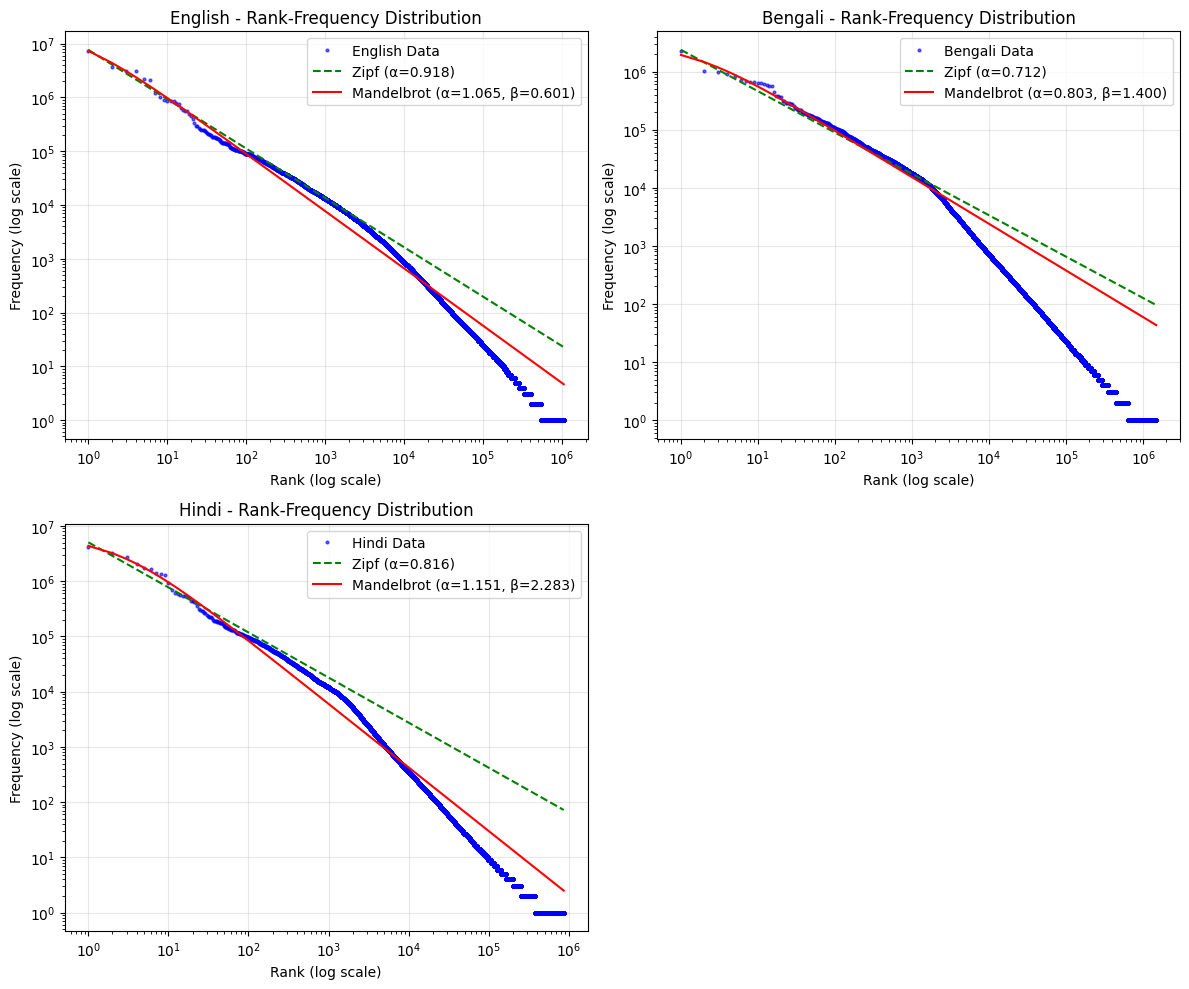


MODEL PARAMETERS AND FIT QUALITY - COMPARISON
+------------+------------------+-------------+------------+----------+---------+
|   Language |            Model |   Alpha (α) |   Beta (β) |       R² |    RMSE |
+============+==================+=============+============+==========+=========+
|    English |       Zipf's Law |    0.91753  |        N/A | 0.980384 | 1429.18 |
+------------+------------------+-------------+------------+----------+---------+
|    English | Mandelbrot's Law |    1.06501  |   0.601082 | 0.985484 | 1229.4  |
+------------+------------------+-------------+------------+----------+---------+
|    Bengali |       Zipf's Law |    0.712155 |        N/A | 0.947999 |  783.95 |
+------------+------------------+-------------+------------+----------+---------+
|    Bengali | Mandelbrot's Law |    0.803298 |   1.399639 | 0.965789 |  635.87 |
+------------+------------------+-------------+------------+----------+---------+
|      Hindi |       Zipf's Law |    0.815882 |    

In [15]:


def zipf_mandelbrot_law_analysis(words,properties):
    if not words:
        return
    
    frequencies, ranks = properties['frequencies'], properties['ranks']
    model_results = zipf_mandelbrot_models(ranks, frequencies)
    deviations = identify_deviation_points(ranks, frequencies, model_results)
    
    return [ranks,frequencies, model_results, deviations]
    
    
    
def zipf_printer(properties):
    
    ranks = [p[0] for p in properties]
    frequencies = [p[1] for p in properties]
    model_results = [p[2] for p in properties]
    deviations = [p[3] for p in properties]
    lang = [p[4] for p in properties]
    
    plot_law_analysis(ranks, frequencies, model_results,lang)
    
    print_zipf_prediction(model_results, lang)
    
    print_zipf_deviation(deviations, lang)
    
print("=" * 50)
print("ZIPF'S LAW ANALYSIS")
print("=" * 50)

zipf_results = []

for l,word_t, word_p in zip(languages,word_tokens,word_properties):
    # print("Zipf's Law for ",l)
    zipf_results.append(zipf_mandelbrot_law_analysis(word_t,word_p)+[l]) # type: ignore
    
zipf_printer(zipf_results)

In [16]:


def analyze_top_words(word_freq_dict, top_percent=5.0):
    total_words = len(word_freq_dict)
    total_frequency = sum(word_freq_dict.values())  # Total occurrences in entire corpus
    
    num_top_words = math.ceil(total_words * top_percent / 100)
    top_words = sorted(word_freq_dict.items(), key=lambda x: x[1], reverse=True)[:num_top_words]
    
    df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])
    df['Rank'] = range(1, len(df) + 1)
    
    df['Percentage'] = (df['Frequency'] / total_frequency) * 100
    
    df['Cumulative_Percentage'] = df['Percentage'].cumsum()
    
    return df

def print_frequent_words(lang,top_words_df, m=7,max_display=70):
    
    print("=" * 50)
    print(f"\nMOST FREQUENT WORDS IN ",lang.upper())
    print("=" * 50)
    print(f"The top {len(top_words_df)} words account for {top_words_df['Cumulative_Percentage'].iloc[-1]:.1f}% of all word occurrences")
    
    words = top_words_df['Word'].tolist()[:max_display]
    n_rows = math.ceil(len(words) / m)
    
    # reshape words into n x m grid
    grid = [words[i*m:(i+1)*m] for i in range(n_rows)]
    
    print(f"\nFrequent words:\n")
    print(tabulate(grid, tablefmt="grid"))


In [17]:

def freuquent_word_analysis(properties,lang):
    
    word_freq_dict = properties['word_freq_dict']
    
    top_words_df = analyze_top_words(word_freq_dict, 5)
    print_frequent_words(lang,top_words_df)
    
for l,word_p in zip(languages,word_properties):
    freuquent_word_analysis(word_p,l)


MOST FREQUENT WORDS IN  ENGLISH
The top 52872 words account for 95.6% of all word occurrences

Frequent words:

+----------+--------+----------+------------+-------+------------+----------+
| the      | of     | in       | and        | a     | to         | was      |
+----------+--------+----------+------------+-------+------------+----------+
| s        | for    | as       | on         | is    | by         | with     |
+----------+--------+----------+------------+-------+------------+----------+
| from     | he     | at       | that       | his   | it         | an       |
+----------+--------+----------+------------+-------+------------+----------+
| were     | also   | which    | are        | new   | this       | be       |
+----------+--------+----------+------------+-------+------------+----------+
| first    | or     | had      | one        | after | its        | has      |
+----------+--------+----------+------------+-------+------------+----------+
| their    | align  | but    

Heap Analysis

In [18]:

def compute_vocabulary_growth(words, sample_points):
    
    total_tokens = len(words)
    step_size = max(1, total_tokens // sample_points)
    
    corpus_sizes = []
    vocabulary_sizes = []
    vocabulary = set()
    
    print(f"Computing vocabulary growth for {total_tokens:,} tokens...")
    
    for i in tqdm(range(len(words))):
        word = words[i]
        vocabulary.add(word)
        
        if i % step_size == 0 or i == total_tokens - 1:
            corpus_sizes.append(i + 1)
            vocabulary_sizes.append(len(vocabulary))
    
    return np.array(corpus_sizes), np.array(vocabulary_sizes),total_tokens,len(vocabulary)


In [19]:
growth_data=[]
corpus_properties=[]

for l,word_t in zip(languages,word_tokens):
    cop,voc,tt,lenv = compute_vocabulary_growth(word_t, 0.01*len(word_t))
    growth_data.append([cop,voc])
    corpus_properties.append([tt,lenv])

Computing vocabulary growth for 113,146,814 tokens...


100%|██████████| 113146814/113146814 [00:26<00:00, 4220297.63it/s]


Computing vocabulary growth for 104,009,930 tokens...


100%|██████████| 104009930/104009930 [00:28<00:00, 3656324.51it/s]


Computing vocabulary growth for 88,757,626 tokens...


100%|██████████| 88757626/88757626 [00:27<00:00, 3257580.90it/s]


In [20]:


def heaps_law(N, K, beta):
    return K * (N ** beta)

def heaps_law_model(corpus_sizes, vocabulary_sizes):
    
    try:
        # Use nonlinear least squares to fit Heaps' law
        def heaps_wrapper(N, K, beta):
            return heaps_law(N, K, beta)
        
        # Initial guesses: K around 10-100, beta around 0.5-0.7 (typical values)
        initial_guess = [50.0, 0.5]
        
        # Fit the model
        params, _ = curve_fit(heaps_wrapper, corpus_sizes, vocabulary_sizes, 
                             p0=initial_guess, maxfev=5000)
        
        K, beta = params
        
        # Calculate predictions and metrics
        predictions = heaps_law(corpus_sizes, K, beta)
        
        
        r2 = r2_score(vocabulary_sizes, predictions)
        mse = mean_squared_error(vocabulary_sizes, predictions)
        rmse = np.sqrt(mse)
        
        return {
            'K': K,
            'beta': beta,
            'r2': r2,
            'mse': mse,
            'rmse': rmse,
            'predictions': predictions
        }
        
    except Exception as e:
        print(f"Error fitting Heaps' law: {e}")
        return None


In [ ]:

def plot_heaps_law(corpus_sizes_list, vocabulary_sizes_list, heaps_results_list, languages):
    
    n_languages = len(languages)
    
    # Determine subplot layout
    n_cols = n_languages  # Maximum 2 columns
    n_rows = (n_languages + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    
    # Flatten axes array for easy indexing
    if n_languages > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    
    plot_colour = 'blue'
    heap_colour = 'red'
    
    for i, (corpus_sizes, vocabulary_sizes, heaps_results, language) in enumerate(zip(
        corpus_sizes_list, vocabulary_sizes_list, heaps_results_list, languages)):
        
        ax = axes[i]
        color = plot_colour
        marker ='o'
        
        # Plot actual data
        ax.plot(corpus_sizes, vocabulary_sizes, marker, markersize=3, alpha=0.7, 
                color=color, label=f'{language} Data')
        
        # Plot fitted Heaps' law
        if heaps_results:
            ax.plot(corpus_sizes, heaps_results['predictions'], '-', linewidth=2,
                    color=heap_colour, 
                    label=f"Heaps' Law (K={heaps_results['K']:.2f}, β={heaps_results['beta']:.3f})")
        
        ax.set_xlabel('Corpus Size')
        ax.set_ylabel('Vocabulary Size')
        ax.set_title(f'{language} - Vocabulary Growth\nR² = {heaps_results["r2"]:.4f}' if heaps_results else f'{language} - Vocabulary Growth')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    
def print_heap_results(heaps_results_list, languages):
    print("=" * 60)
    print("\nHEAPS' LAW PARAMETERS - COMPARISON")
    print("=" * 60)
    
    # Prepare data for tabulate
    table_data = []
    headers = ["Language", "K parameter", "β parameter", "R² score", "MSE", "RMSE"]
    
    for language, results in zip(languages, heaps_results_list):
        table_data.append([
            language,
            f"{results['K']:.4f}",
            f"{results['beta']:.4f}",
            f"{results['r2']:.4f}",
            f"{results['mse']:.4f}",
            f"{results['rmse']:.4f}"
        ])
    
    # Print the table
    print(tabulate(table_data, headers=headers, tablefmt="grid", stralign="right"))
    
    # Print individual language analysis
    print("\n" + "=" * 60)
    print("INDIVIDUAL LANGUAGE ANALYSIS:")
    print("=" * 60)
    
    for language, results in zip(languages, heaps_results_list):
        # Evaluate fit quality for each language
        r2 = results['r2']
        if r2 >= 0.95:
            fit_quality = "Excellent fit"
        elif r2 >= 0.90:
            fit_quality = "Good fit"
        elif r2 >= 0.85:
            fit_quality = "Reasonable fit"
        else:
            fit_quality = "Poor fit"
        
        # Check if parameters are within typical ranges
        k = results['K']
        beta = results['beta']
        
        print(f"• {language}: {fit_quality} (R² = {r2:.4f})")
        print(f"  K = {k:.4f}, β = {beta:.4f}")



HEAPS' LAW ANALYSIS


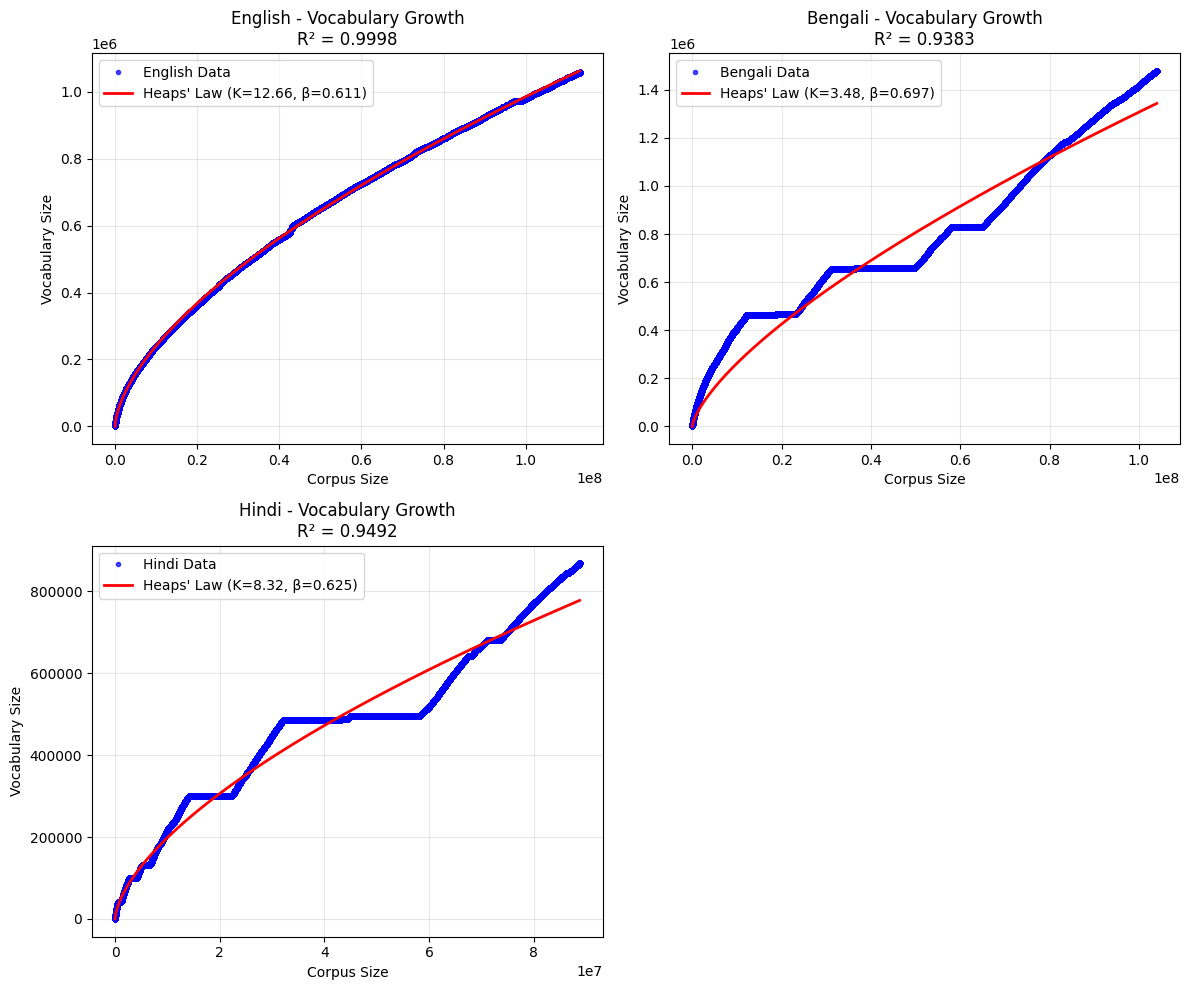


HEAPS' LAW PARAMETERS - COMPARISON
+------------+---------------+---------------+------------+-------------+----------+
|   Language |   K parameter |   β parameter |   R² score |         MSE |     RMSE |
+============+===============+===============+============+=============+==========+
|    English |       12.6594 |        0.6114 |     0.9998 | 1.62523e+07 |  4031.42 |
+------------+---------------+---------------+------------+-------------+----------+
|    Bengali |        3.4808 |        0.6968 |     0.9383 | 7.44698e+09 | 86295.9  |
+------------+---------------+---------------+------------+-------------+----------+
|      Hindi |        8.3246 |        0.6254 |     0.9492 | 2.07629e+09 | 45566.3  |
+------------+---------------+---------------+------------+-------------+----------+

INDIVIDUAL LANGUAGE ANALYSIS:
• English: Excellent fit (R² = 0.9998)
  K = 12.6594, β = 0.6114
• Bengali: Good fit (R² = 0.9383)
  K = 3.4808, β = 0.6968
• Hindi: Good fit (R² = 0.9492)
  K = 8.3246

In [22]:

def analyze_heaps_law(words, growth):
    
    if not words:
        return None
    
    # Compute vocabulary growth
    corpus_sizes, vocabulary_sizes = growth
    
    # Fit Heaps' law
    heaps_results = heaps_law_model(corpus_sizes, vocabulary_sizes)
        
    
    return heaps_results

def heap_printer(growth, heap_results, lang):
    
    corpus_sizes = [g[0] for g in growth]
    vocabulary_sizes = [g[1] for g in growth]
    
    plot_heaps_law(corpus_sizes, vocabulary_sizes, heap_results, lang)
    
    print_heap_results(heaps_results, lang)

print("\n" + "="*60)
print("HEAPS' LAW ANALYSIS")
print("="*60)

heaps_results=[]

for l,word_t,growth_d in zip(languages,word_tokens,growth_data):
    
    
    heaps_results.append(analyze_heaps_law(word_t, growth_d))
    
heap_printer(growth_data, heaps_results, languages)

Scaling Memory

In [23]:
def memory_requirement(vocab_size):
    
    bytes_needed = vocab_size * 8
    by =bytes_needed
    mb = bytes_needed / (1024**2)
    gb = bytes_needed / (1024**3)
    tb = bytes_needed / (1024**4)
    return by,mb, gb, tb


def summarize_corpora(file_paths,growth):
    
    table = []
    mem = []
    headers = ["Corpus", "Vocabulary", "Memory (MB)", "Memory (GB)", "Memory (TB)", "Fits in Machine?"]

    # Get available RAM in bytes
    available_ram = psutil.virtual_memory().available
    available_gb = available_ram / (1024**3)

    for file,gr in zip(file_paths,growth):
        # V = corpus_stats(file)
        T = gr[0]
        V = gr[1]
        by, mb, gb, tb = memory_requirement(V)
        
        fits = "Yes" if (gb <= available_gb) else "No"
        
        mem.append({})
        mem[-1]["Corpus Size"]=T
        mem[-1]["Vocabulary Size"]=V
        mem[-1]["Memory Size"]=by
        mem[-1]["Fits"]=fits      

        table.append([os.path.basename(file),f"{V:,}",f"{mb:,.2f}",f"{gb:,.2f}",f"{tb:,.3f}",fits])

    print(tabulate(table, headers=headers))
    print(f"\nAvailable system RAM: {available_gb:.2f} GB")
    
    return mem



memory_properties=summarize_corpora(corpus_files, corpus_properties)

Corpus                 Vocabulary      Memory (MB)    Memory (GB)    Memory (TB)  Fits in Machine?
---------------------  ------------  -------------  -------------  -------------  ------------------
english_processed.txt  1,057,440              8.07           0.01              0  Yes
bengali_processed.txt  1,478,174             11.28           0.01              0  Yes
hindi_processed.txt    868,332                6.62           0.01              0  Yes

Available system RAM: 0.46 GB


Regression on Heap's Law

In [24]:

def heaps_law_regression(corpus_sizes, vocabulary_sizes):
    
    valid_indices = (corpus_sizes > 0) & (vocabulary_sizes > 0)
    corpus_sizes = corpus_sizes[valid_indices]
    vocabulary_sizes = vocabulary_sizes[valid_indices]
    
    # Log-transform the data with safety checks
    log_N = np.log(corpus_sizes)
    log_V = np.log(vocabulary_sizes)
    
    # Remove infinite values (just in case)
    finite_mask = np.isfinite(log_N) & np.isfinite(log_V)
    log_N = log_N[finite_mask]
    log_V = log_V[finite_mask]

    
    model = LinearRegression()
    model.fit(log_N.reshape(-1, 1), log_V)
    
    # Extract parameters
    beta = model.coef_[0]
    log_K = model.intercept_
    K = np.exp(log_K)
    
    # Calculate predictions
    log_pred = model.predict(log_N.reshape(-1, 1))
    predictions = np.exp(log_pred)

    # Calculate additional metrics
    r2 = r2_score(log_V, log_pred)
    mse = mean_squared_error(vocabulary_sizes, predictions)
    rmse = np.sqrt(mse)
    
    return {
        'K': K,
        'beta': beta,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'predictions': predictions
    }

In [25]:


import matplotlib.pyplot as plt
import numpy as np

def plot_heaps_law_regression(corpus_sizes_list, vocabulary_sizes_list, results_list, languages):
    
    n_languages = len(languages)
    
    # Determine subplot layout
    n_cols = min(2, n_languages)  # Maximum 2 columns
    n_rows = (n_languages + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    
    # Flatten axes array for easy indexing
    if n_languages > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    plot_color = 'blue'
    regression_colour = 'red'
    
    for i, (corpus_sizes, vocabulary_sizes, results, language) in enumerate(zip(
        corpus_sizes_list, vocabulary_sizes_list, results_list, languages)):
        
        ax = axes[i]
        marker = 'o'
        
        # Plot actual data
        ax.plot(corpus_sizes, vocabulary_sizes, marker, markersize=3, alpha=0.7, 
                color=plot_color, label=f'{language} Data')
        
        # Plot fitted Heaps' law
        ax.plot(corpus_sizes, results['predictions'], '-', linewidth=2,
                color=regression_colour, 
                label=f'Heaps\' Law Fit (K={results["K"]:.2f}, β={results["beta"]:.3f})')
        
        ax.set_xlabel('Corpus Size (log scale)')
        ax.set_ylabel('Vocabulary Size (log scale)')
        ax.set_title(f'{language} - Heaps\' Law (Regression)\nR² = {results["r2"]:.4f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xscale('log')
        ax.set_yscale('log')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

    
from tabulate import tabulate

def print_regression_results(results_list, languages):
    
    print("=" * 80)
    print(f"\nHEAPS' LAW FITTING RESULTS (Linear Regression on Log-Transformed Data)")
    print("=" * 80)
    
    # Prepare data for tabulate
    table_data = []
    headers = ["Language", "K parameter", "β parameter", "R² score", "MSE", "RMSE"]
    
    for language, results in zip(languages, results_list):
        table_data.append([
            language,
            f"{results['K']:.4f}",
            f"{results['beta']:.4f}",
            f"{results['r2']:.4f}",
            f"{results['mse']:.4f}",
            f"{results['rmse']:.4f}"
        ])
    
    # Print the table
    print(tabulate(table_data, headers=headers, tablefmt="grid", stralign="right"))
    
    # Print individual fit assessment
    print("\n" + "=" * 80)
    print("FIT QUALITY ASSESSMENT:")
    print("=" * 80)
    
    for language, results in zip(languages, results_list):
        r2 = results['r2']
        if r2 >= 0.95:
            assessment = "Excellent fit"
        elif r2 >= 0.90:
            assessment = "Good fit"
        elif r2 >= 0.85:
            assessment = "Reasonable fit"
        else:
            assessment = "Poor fit"
        
        print(f"• {language}: {assessment} (R² = {r2:.4f})")


In [26]:

def analyze_regression(words,growth):
    
    if not words:
        return None
    
    
    # Compute vocabulary growth
    corpus_sizes, vocabulary_sizes = growth
    
    # Fit using linear regression on log-transformed data
    results = heaps_law_regression(corpus_sizes, vocabulary_sizes)
    
    return results

def regression_printer(growth,results,lang):

    corpus_sizes = [g[0] for g in growth]
    vocabulary_sizes = [g[1] for g in growth]
    plot_heaps_law_regression(corpus_sizes, vocabulary_sizes, results, lang)
    print_regression_results(results,lang)


HEAP'S LAW via REGRESSION 


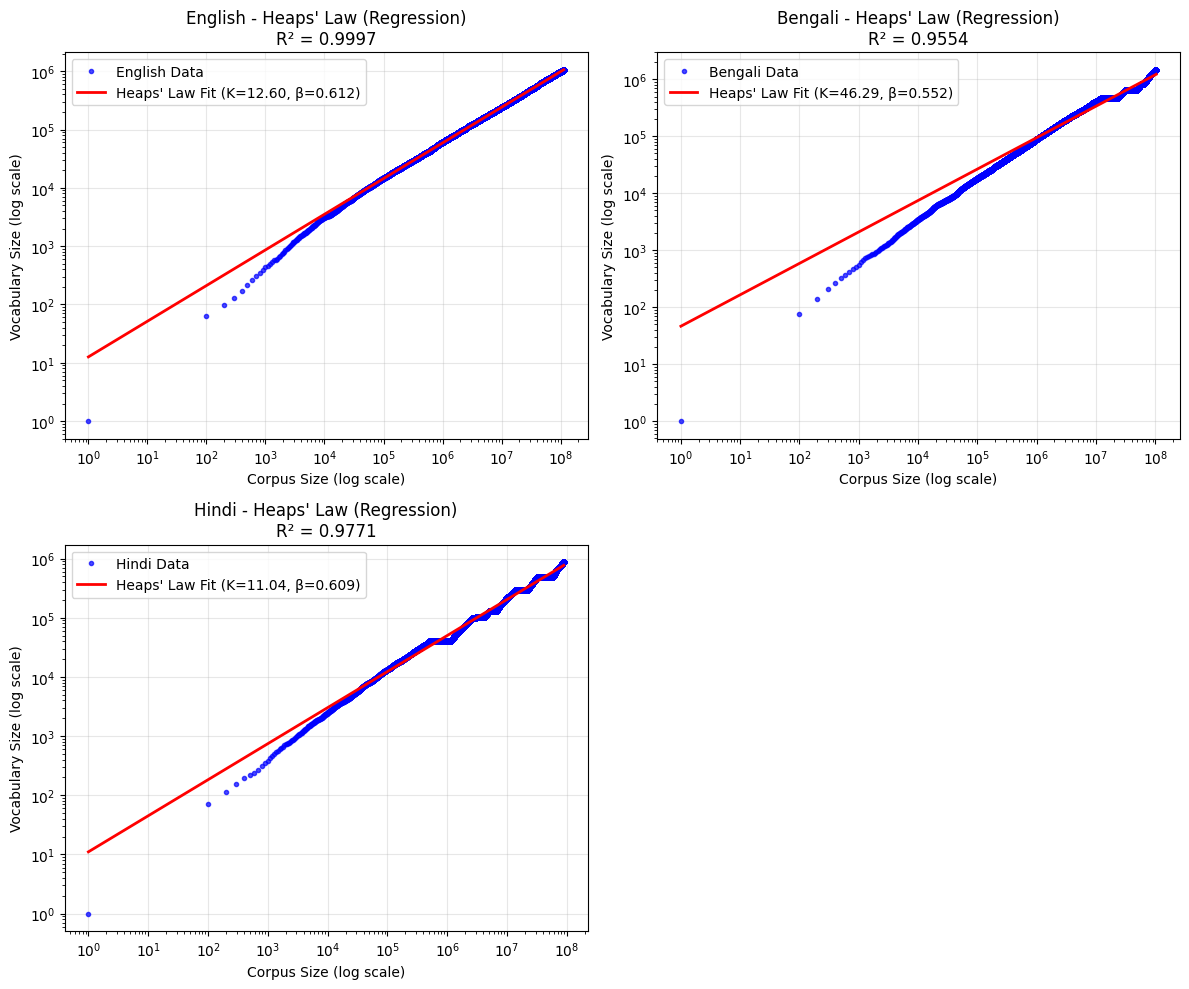


HEAPS' LAW FITTING RESULTS (Linear Regression on Log-Transformed Data)
+------------+---------------+---------------+------------+-------------+-----------+
|   Language |   K parameter |   β parameter |   R² score |         MSE |      RMSE |
+============+===============+===============+============+=============+===========+
|    English |       12.6029 |        0.6116 |     0.9997 | 1.63414e+07 |   4042.45 |
+------------+---------------+---------------+------------+-------------+-----------+
|    Bengali |       46.2889 |        0.5518 |     0.9554 | 1.04786e+10 | 102365    |
+------------+---------------+---------------+------------+-------------+-----------+
|      Hindi |       11.042  |        0.6093 |     0.9771 | 2.09315e+09 |  45751    |
+------------+---------------+---------------+------------+-------------+-----------+

FIT QUALITY ASSESSMENT:
• English: Excellent fit (R² = 0.9997)
• Bengali: Excellent fit (R² = 0.9554)
• Hindi: Excellent fit (R² = 0.9771)


In [27]:

print("=" * 40)
print("HEAP'S LAW via REGRESSION ",)
print("=" * 40)

regression_results=[]

for l,word_t,growth_d in zip(languages,word_tokens,growth_data):
    
    regression_results.append(analyze_regression(word_t, growth_d))
    
regression_printer(growth_data,regression_results,languages)


Comparison

In [ ]:
def compare_fitting_methods(regression_results, curve_fit_results):
    
    # Create comparison data
    comparison_data = [
        {
            'Method': 'Linear Regression (Log-Transformed)',
            'K': regression_results['K'],
            'β': regression_results['beta'],
            'R²': regression_results['r2'],
            'MSE': regression_results['mse'],
            'RMSE': regression_results['rmse']
        },
        {
            'Method': 'Direct Curve Fitting',
            'K': curve_fit_results['K'],
            'β': curve_fit_results['beta'],
            'R²': curve_fit_results['r2'],
            'MSE': curve_fit_results['mse'],
            'RMSE': curve_fit_results['rmse']
        }
    ]
    
    # Create DataFrame
    df = pd.DataFrame(comparison_data)
    
    # Calculate differences
    k_diff = abs(df.loc[0, 'K'] - df.loc[1, 'K']) / df.loc[0, 'K'] * 100 # type: ignore
    beta_diff = abs(df.loc[0, 'β'] - df.loc[1, 'β']) / df.loc[0, 'β'] * 100 # type: ignore
    r2_diff = df.loc[0, 'R²'] - df.loc[1, 'R²'] # type: ignore
    
    # Print detailed comparison
    print("=" * 100)
    print(df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))
    print("\n" + "=" * 100)
    print("PARAMETER DIFFERENCES:")
    print(f"K parameter difference: {k_diff:.2f}%")
    print(f"β parameter difference: {beta_diff:.2f}%")
    print(f"R² difference: {abs(r2_diff):.6f}") # type: ignore
    
    # Determine which method fits better
    if regression_results['r2'] > curve_fit_results['r2']:
        better_method = "Linear Regression (Log-Transformed)"
        improvement = regression_results['r2'] - curve_fit_results['r2']
        print(f"\nBetter fit: {better_method} (R² improvement: {improvement:.6f})")
    elif curve_fit_results['r2'] > regression_results['r2']:
        better_method = "Direct Curve Fitting"
        improvement = curve_fit_results['r2'] - regression_results['r2']
        print(f"\nBetter fit: {better_method} (R² improvement: {improvement:.6f})")
    else:
        print(f"\nBoth methods provide identical fit quality")



# Compare the methods

for l,reg,heap in zip(languages,regression_results,heaps_results):
    print("\nCOMPARING MODELS for ",l)
    compare_fitting_methods(reg, heap)


\COMPARING MODELS for  English
                             Method         K        β       R²             MSE        RMSE
Linear Regression (Log-Transformed) 12.602865 0.611593 0.999739 16341426.842344 4042.453072
               Direct Curve Fitting 12.659411 0.611368 0.999778 16252321.474679 4031.416807

PARAMETER DIFFERENCES:
K parameter difference: 0.45%
β parameter difference: 0.04%
R² difference: 0.000039

Better fit: Direct Curve Fitting (R² improvement: 0.000039)

\COMPARING MODELS for  Bengali
                             Method         K        β       R²                MSE          RMSE
Linear Regression (Log-Transformed) 46.288881 0.551802 0.955426 10478641736.731604 102365.236954
               Direct Curve Fitting  3.480764 0.696814 0.938326  7446984685.070401  86295.913490

PARAMETER DIFFERENCES:
K parameter difference: 92.48%
β parameter difference: 26.28%
R² difference: 0.017101

Better fit: Linear Regression (Log-Transformed) (R² improvement: 0.017101)

\COMPARING MO

<>:57: SyntaxWarning: invalid escape sequence '\C'
<>:57: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_38466/858319799.py:57: SyntaxWarning: invalid escape sequence '\C'
  print("\n\COMPARING MODELS for ",l)


In [29]:

def compare_all_languages(zipf, heap_list, regression_list, mem_list, languages):
    
    zipf_list = [z[2] for z in zipf]
    
    # Prepare data for the comparison table
    comparison_data = []
    
    # Zipf's Law parameters
    comparison_data.append(["Zipf's Law - α (Zipf)"] + [f"{zipf['zipf']['alpha']:.4f}" for zipf in zipf_list])
    comparison_data.append(["Zipf's Law - α (Mandelbrot)"] + [f"{zipf['mandelbrot']['alpha']:.4f}" for zipf in zipf_list])
    comparison_data.append(["Zipf's Law - β (Mandelbrot)"] + [f"{zipf['mandelbrot']['beta']:.4f}" for zipf in zipf_list])
    comparison_data.append(["Zipf's Law - R² (Zipf)"] + [f"{zipf['zipf']['r2']:.4f}" for zipf in zipf_list])
    comparison_data.append(["Zipf's Law - R² (Mandelbrot)"] + [f"{zipf['mandelbrot']['r2']:.4f}" for zipf in zipf_list])
    comparison_data.append(["Zipf's Law - Best Fit"] + [
        "Mandelbrot" if zipf['mandelbrot']['r2'] > zipf['zipf']['r2'] else "Zipf" 
        for zipf in zipf_list
    ])
    
    # Add separator
    comparison_data.append(["-" * 30] + ["-" * 15] * len(languages))
    
    # Heaps' Law parameters
    comparison_data.append(["Heaps' Law - K"] + [f"{heap['K']:.4f}" for heap in heap_list])
    comparison_data.append(["Heaps' Law - β"] + [f"{heap['beta']:.4f}" for heap in heap_list])
    comparison_data.append(["Heaps' Law - R²"] + [f"{heap['r2']:.4f}" for heap in heap_list])
    comparison_data.append(["Heaps' Law - Fit Quality"] + [
        "Excellent" if heap['r2'] >= 0.95 else "Good" if heap['r2'] >= 0.90 else "Reasonable" 
        for heap in heap_list
    ])
    
    # Add separator
    comparison_data.append(["-" * 30] + ["-" * 15] * len(languages))
    
    # Regression results (Heaps)
    comparison_data.append(["Regression - K"] + [f"{reg['K']:.4f}" for reg in regression_list])
    comparison_data.append(["Regression - β"] + [f"{reg['beta']:.4f}" for reg in regression_list])
    comparison_data.append(["Regression - R²"] + [f"{reg['r2']:.4f}" for reg in regression_list])
    
    # Add separator
    comparison_data.append(["-" * 30] + ["-" * 15] * len(languages))
    
    # Memory requirements
    comparison_data.append(["Corpus Size (tokens)"] + [f"{mem['Corpus Size']:,}" for mem in mem_list])
    comparison_data.append(["Vocabulary Size"] + [f"{mem['Vocabulary Size']:,}" for mem in mem_list])
    comparison_data.append(["Memory Required"] + [str(int((mem['Memory Size']/1e6)*100)/100)+" MB"for mem in mem_list])
    comparison_data.append(["Fits in Memory"] + [mem['Fits'] for mem in mem_list])
    
    # Create headers
    headers = ["Property"] + languages
    
    # Print the comprehensive comparison table
    print("\nCOMPREHENSIVE LANGUAGE COMPARISON")
    print("=" * 80)
    print(tabulate(comparison_data, headers=headers, tablefmt="grid", stralign="right"))
    
    # Additional insights
    print("\n" + "=" * 80)
    print("KEY INSIGHTS:")
    print("=" * 80)
    
    # Zipf's Law insights
    best_zipf_idx = np.argmax([zipf['mandelbrot']['r2'] for zipf in zipf_list])
    print(f"• Best Zipf's Law fit: {languages[best_zipf_idx]} (R² = {zipf_list[best_zipf_idx]['mandelbrot']['r2']:.4f})")
    
    # Heaps' Law insights
    best_heap_idx = np.argmax([heap['r2'] for heap in heap_list])
    print(f"• Best Heaps' Law fit: {languages[best_heap_idx]} (R² = {heap_list[best_heap_idx]['r2']:.4f})")
    
    # Regression insights
    best_reg_idx = np.argmax([reg['r2'] for reg in regression_list])
    print(f"• Best Regression fit: {languages[best_reg_idx]} (R² = {regression_list[best_reg_idx]['r2']:.4f})")
    
    # Memory insights
    largest_vocab_idx = np.argmax([mem['Vocabulary Size'] for mem in mem_list])
    print(f"• Largest vocabulary: {languages[largest_vocab_idx]} ({mem_list[largest_vocab_idx]['Vocabulary Size']:,} words)")


compare_all_languages(zipf_results, heaps_results, regression_results, memory_properties, languages)


COMPREHENSIVE LANGUAGE COMPARISON
+--------------------------------+-----------------+-----------------+-----------------+
|                       Property |         English |         Bengali |           Hindi |
+================================+=================+=================+=================+
|          Zipf's Law - α (Zipf) |          0.9175 |          0.7122 |          0.8159 |
+--------------------------------+-----------------+-----------------+-----------------+
|    Zipf's Law - α (Mandelbrot) |          1.0650 |          0.8033 |          1.1511 |
+--------------------------------+-----------------+-----------------+-----------------+
|    Zipf's Law - β (Mandelbrot) |          0.6011 |          1.3996 |          2.2834 |
+--------------------------------+-----------------+-----------------+-----------------+
|         Zipf's Law - R² (Zipf) |          0.9804 |          0.9480 |          0.9506 |
+--------------------------------+-----------------+-----------------+-----